In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,root_mean_squared_error,mean_absolute_error,r2_score
from sklearn.preprocessing import PolynomialFeatures

In [4]:
df = pd.read_csv("Ice_cream selling data.csv")

In [5]:
df

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [6]:
df.columns

Index(['Temperature (°C)', 'Ice Cream Sales (units)'], dtype='object')

In [7]:
x = df[['Temperature (°C)']]
y = df['Ice Cream Sales (units)']

In [8]:
x

,Temperature (°C)
0,-4.662263
1,-4.316559
2,-4.213985
3,-3.949661
4,-3.578554
5,-3.455712
6,-3.108440
7,-3.081303
8,-2.672461
9,-2.652287


In [9]:
y

0     41.842986
1     34.661120
2     39.383001
3     37.539845
4     32.284531
5     30.001138
6     22.635401
7     25.365022
8     19.226970
9     20.279679
10    13.275828
11    18.123991
12    11.218294
13    10.012868
14    12.615181
15    10.957731
16     6.689123
17     9.392969
18     5.210163
19     4.673643
20     0.328626
21     0.897603
22     3.165600
23     1.931416
24     2.576782
25     4.625689
26     0.789974
27     2.313806
28     1.292361
29     0.953115
30     3.782570
31     4.857988
32     8.943823
33     8.170735
34     7.412094
35    10.336631
36    15.996620
37    12.568237
38    21.342916
39    20.114413
40    22.839406
41    16.983279
42    25.142082
43    26.104740
44    28.912188
45    17.843957
46    34.530743
47    27.698383
48    41.514822
Name: Ice Cream Sales (units), dtype: float64

In [10]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


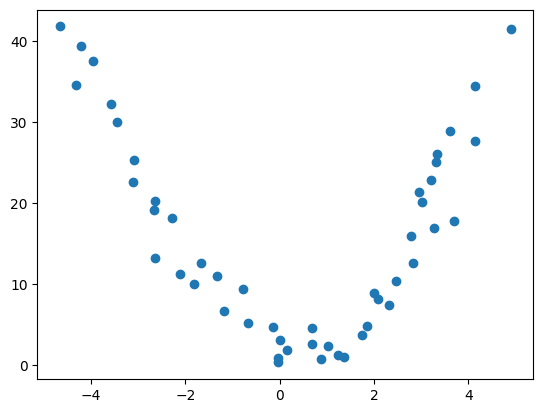

In [11]:
plt.scatter(x,y)

In [12]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size=0.8,random_state=42)

In [13]:
model = LinearRegression()

In [14]:
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
model.predict(xtest)

array([19.2247831 , 12.89218952, 12.39975758, 12.99914196, 18.0259032 ,
       15.96490086, 16.13605851, 16.34394177, 15.0173946 , 17.3107825 ])

In [16]:
slope = model.coef_
slope

array([-1.14658686])

In [17]:
intercept = model.intercept_
intercept

np.float64(17.139213127718417)

In [18]:
y_pred_train = model.predict(xtrain)

In [19]:
r2_score(ytrain,y_pred_train)

0.06579063815950037

In [20]:
root_mean_squared_error(xtrain,y_pred_train)

18.133335860530735

In [21]:
mean_absolute_error(xtrain,y_pred_train)

17.130059165330785

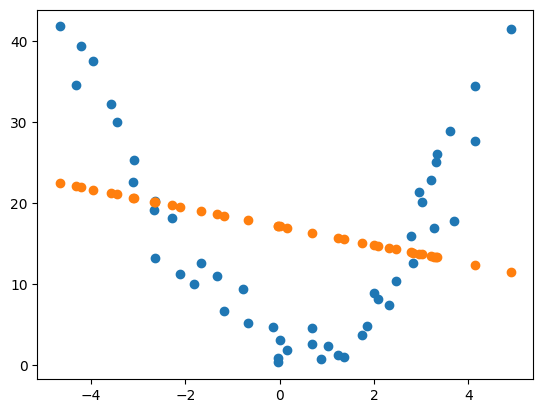

In [22]:
plt.scatter(x,y)
plt.scatter(xtrain,y_pred_train)

for the above non-linear data we need to use ploynominal features

In [23]:
poly = PolynomialFeatures(degree=3)
updated_xtrain = poly.fit_transform(xtrain)
updated_xtest = poly.transform(xtest)

In [24]:
xtrain.head()

,Temperature (°C)
12,-2.111870
4,-3.578554
34,2.318591
8,-2.672461
3,-3.949661


In [25]:
updated_xtrain

array([[ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00,
        -9.41892528e+00],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01,
        -4.58271260e+01],
       [ 1.00000000e+00,  2.31859124e+00,  5.37586534e+00,
         1.24644343e+01],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00,
        -1.90868405e+01],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01,
        -6.16140128e+01],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00,
        -3.00349918e+01],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01,
         3.31184096e+01],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01,
         3.49671967e+01],
       [ 1.00000000e+00,  4.13086796e+00,  1.70640701e+01,
         7.04894205e+01],
       [ 1.00000000e+00, -1.32637898e+00,  1.75928121e+00,
        -2.33347362e+00],
       [ 1.00000000e+00, -2.65228679e+00,  7.03462523e+00,
        -1.86578436e+01],
       [ 1.00000000e+00, -1.17312327e+00,  1.37621820e+00,
      

In [26]:
model = LinearRegression()
model.fit(updated_xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
#ScatterPlots
'''
ypred_train = model.predict(xtrain)
'''

'\nypred_train = model.predict(xtrain)\n'

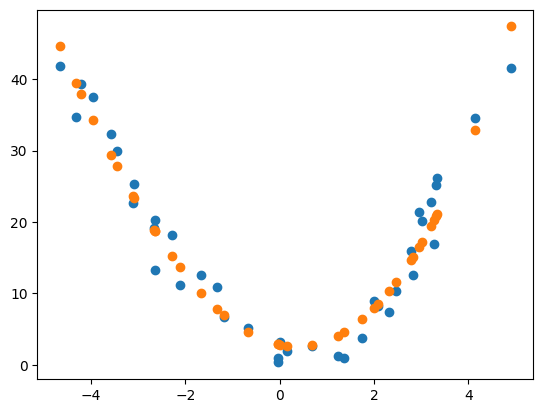

In [28]:
y_pred_train = model.predict(updated_xtrain)
plt.scatter(updated_xtrain[:,1],ytrain)
plt.scatter(updated_xtrain[:,1],y_pred_train)

In [29]:
updated_xtrain[:,1]

array([-2.11186969, -3.57855372,  2.31859124, -2.67246083, -3.94966109,
       -3.10844012,  3.21136614,  3.27004407,  4.13086796, -1.32637898,
       -2.65228679, -1.17312327,  0.68878091,  2.0751006 ,  1.74000001,
       -4.66226268,  3.33593241,  1.99931037, -3.4557117 ,  1.35981267,
       -2.288264  ,  2.78483646, -4.31655945, -0.03389529, -4.21398476,
        2.83176021,  2.471946  ,  0.14924457,  3.02087431, -2.65149803,
        0.0086077 , -0.6737528 ,  4.89903151, -0.0361565 , -3.08130332,
        3.31607252, -1.66034773,  1.24071162,  2.95993209])

In [30]:
# Train Score
train_score = r2_score(ytrain,y_pred_train)
print(f"Train Score: {train_score}")

Train Score: 0.9469116778215552


In [31]:
y_pred_test = model.predict(updated_xtest)
test_score = r2_score(ytest,y_pred_test)
print(f"Test score: {test_score}")

Test score: 0.8405107685716915


### degree = 2
* Train Score: 0.9413665676490518
* Test score: 0.843055137193884

### degree = 3
* Train Score: 0.9469116778215552
* Test score: 0.8405107685716915
### degree = 4
* Train Score: 0.9590068634754769
* Test score: 0.8054468908427623
### degree = 5
* Train Score: 0.9625276778765787
* Test score: 0.7781622233034887
### degree = 6
* Train Score: 0.9668204963106728
* Test score: 0.7313950333963021


### How to check which is best degree?

* we have to check train score and test score by comparing the both train and test scores we can conclude the best degree value!!
* here degree 2 is best
### how to check and conclude which degree is best for the non - linear data?

* for non - linear data which are like U patterns we can go with the degree 2
* for other non linear data patterns we need to check one by one by incereasing the degree and conclude based on the train and test score
* WE get the best degree in between 2 and 8 

### if the polynomial features not performing well then we can go for tree based model which works well for non - linear data

In [32]:
train_mae = mean_absolute_error(ytrain,y_pred_train)
test_mae = mean_absolute_error(ytest,y_pred_test)
print(f"Train MAE Score: {train_mae}")
print(f"Test MAE Score: {test_mae}")

Train MAE Score: 2.43566416014849
Test MAE Score: 3.228121129776889


### MAE when degree=2
* Train MAE Score: 2.5993732834161136
* Test MAE Score: 3.2299819836597274
### MAE when degree=3
* Train MAE Score: 2.43566416014849
* Test MAE Score: 3.228121129776889

In [33]:
train_rmse = root_mean_squared_error(ytrain,y_pred_train)
test_rmse = root_mean_squared_error(ytest,y_pred_test)
print(f"Train RMSE Score: {train_rmse}")
print(f"Test RMSE Score: {test_rmse}")

Train RMSE Score: 2.8539631962901724
Test RMSE Score: 3.888445634341502


### RMSE when degree=2
* Train RMSE Score: 2.99931118717202
* Test RMSE Score: 3.857304297171988
### RMSE when degree=3
* Train RMSE Score: 2.8539631962901724
* Test RMSE Score: 3.888445634341502
